In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
crop_df = pd.read_csv('India_Agriculture_Crop_Production.csv')

## 🟢 **1. Understanding the Dataset**

1. How many **States**, **Districts**, and **Crops** are present?

In [4]:
states = crop_df['State'].nunique()
district = crop_df['District'].nunique()

crop_df.dropna(subset='Crop',inplace=True)
crop = crop_df['Crop'].nunique()
print(f'there are {states} different states (including the union territories), {district} different districts and {crop} different states crops are present in the dataset')

there are 36 different states (including the union territories), 729 different districts and 56 different states crops are present in the dataset


2. What is the **time period** covered? (Min–Max Year)

In [5]:
Year = crop_df['Year'].str.split('-').str[0].astype(int)
minYear = Year.min()
maxYear  =Year.max()
print(f'{minYear}, {maxYear}, timeperiod = {maxYear-minYear} years')

1997, 2020, timeperiod = 23 years


3. Which **Seasons** are included? (Kharif, Rabi, etc.)

In [6]:
print(crop_df['Season'].dropna().unique())

['Kharif' 'Whole Year' 'Rabi' 'Autumn' 'Summer' 'Winter']


4. Are there any **regions/districts/crops** with very few records?

In [7]:
crop_df.columns
new= crop_df.groupby(['State','District','Crop'])['Production'].count().reset_index()
mini = new['Production'].min()
new[new['Production']==mini]
print('yes there are some regions/districts/crops which have very few records')

yes there are some regions/districts/crops which have very few records


## 🟡 **2. Data Quality Checks**

5. Are there **missing values** in Area or Production?

In [8]:
display(crop_df.loc[(crop_df['Production'].isna()),['State']].count())
display(crop_df.loc[(crop_df['Area'].isna()),['State']].count())
crop_df.dropna()
print('Yes there does exist such values')


State    4961
dtype: int64

State    1
dtype: int64

Yes there does exist such values


6. Are there districts with **zero Area but non-zero Production**? (data error)

In [9]:
print(crop_df.loc[crop_df['Area'].isna(),['Production']].count())
print('No there is no data error')

Production    0
dtype: int64
No there is no data error


7. Are there **duplicate** rows for the same (State, District, Year, Crop)?

In [10]:
print(crop_df[['State','District','Year','Crop']].duplicated().sum())
print('Yes there are some duplicated values for the same( States, District, Year, Crop)')


47893
Yes there are some duplicated values for the same( States, District, Year, Crop)


8. Check if **Area** and **Production** values have extreme outliers. doubt

In [11]:
crop_df[['Production','Area']].describe() 

,Production,Area
count,3.404140e+05,3.453740e+05
mean,9.583711e+05,1.167019e+04
std,2.152986e+07,4.583843e+04
min,0.000000e+00,4.000000e-03
25%,8.700000e+01,7.400000e+01
50%,7.170000e+02,5.320000e+02
75%,7.176000e+03,4.110000e+03
max,1.597800e+09,8.580100e+06


9. Is **Yield = Production/Area** realistic? Any unrealistic yield ratios? doubt

## 🔵 **3. Descriptive Statistics**

10. What is the **average cultivated area** per crop?

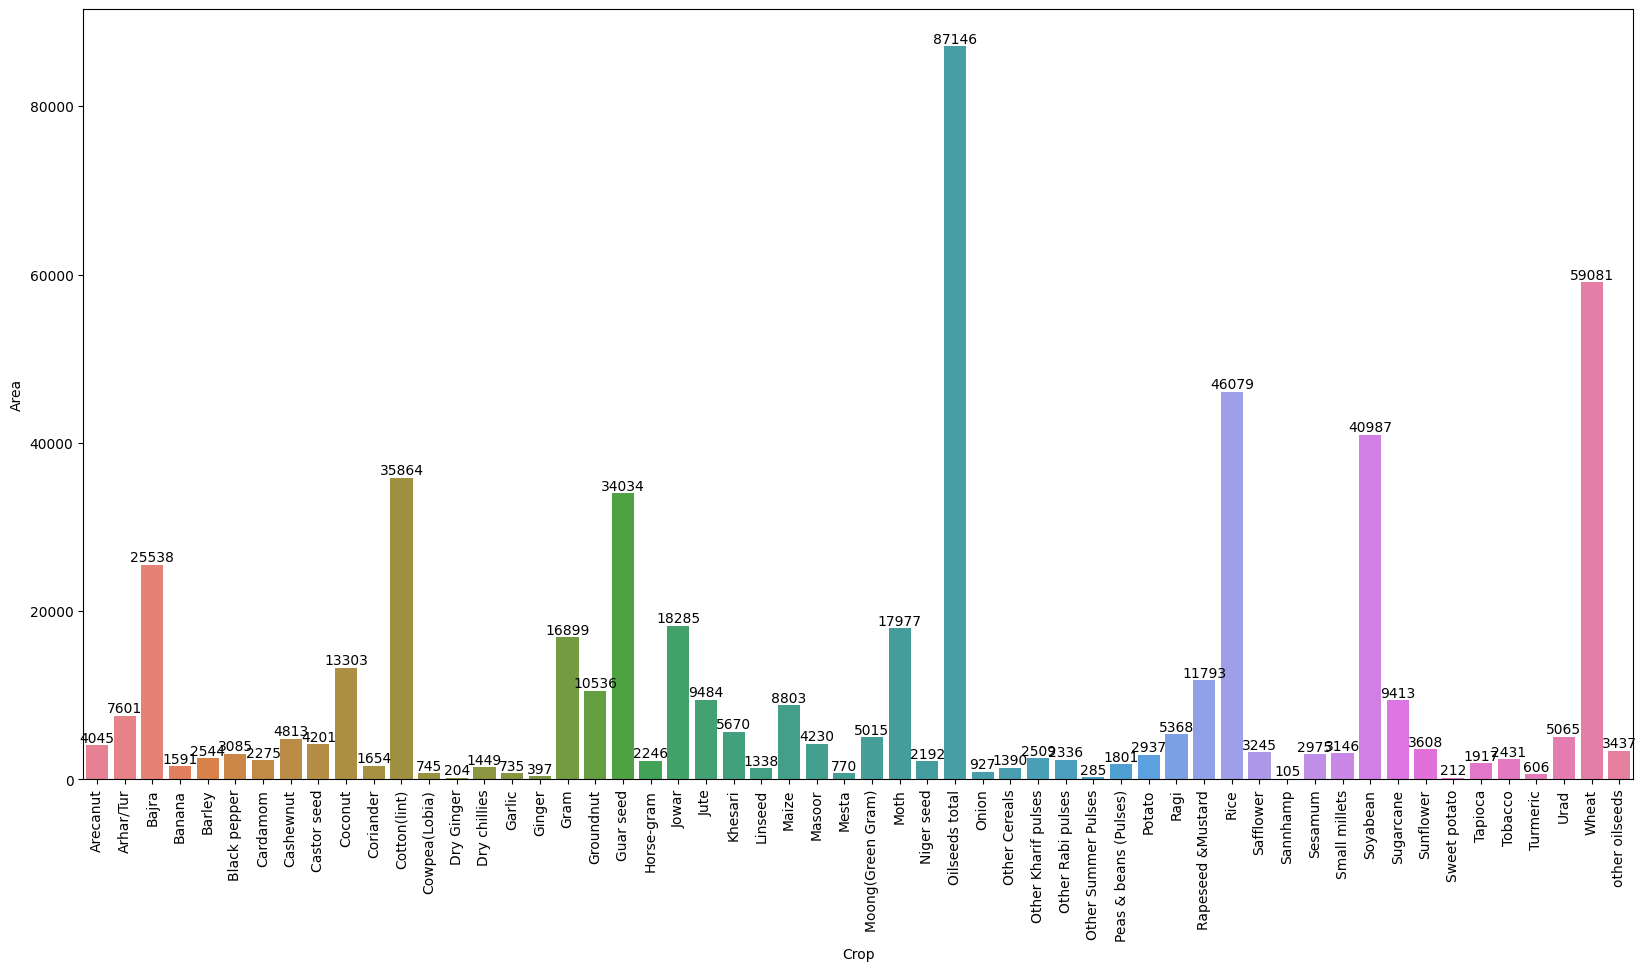

In [12]:
new = crop_df.groupby('Crop')['Area'].mean().astype('int64').reset_index()
plt.figure(figsize=(20,10))
ax = sns.barplot(x='Crop',y='Area',data=new,hue='Crop')
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=90)
plt.show()

11. What is the **average production** per crop?

In [13]:
new=crop_df.groupby('Crop')['Production'].mean().astype('int64').reset_index()
new
# new = new[new['Crop'] != 'Coconut']
# plt.figure(figsize=(20,10))
# ax = sns.barplot(x='Crop',y='Production',data=new,hue='Crop')
# for container in ax.containers:
#     ax.bar_label(container)
# plt.xticks(rotation=90)
# plt.show()

,Crop,Production
0,Arecanut,18278
1,Arhar/Tur,5686
2,Bajra,25925
3,Banana,51718
4,Barley,6038
5,Black pepper,1530
6,Cardamom,528
7,Cashewnut,2462
8,Castor seed,6216
9,Coconut,107507704


12. Which crop has the **highest average yield**?

Crop with highest average yield in Nuts is Coconut
Crop with highest average yield in Tonnes is Sugarcane
Crop with highest average yield in Bales is Jute


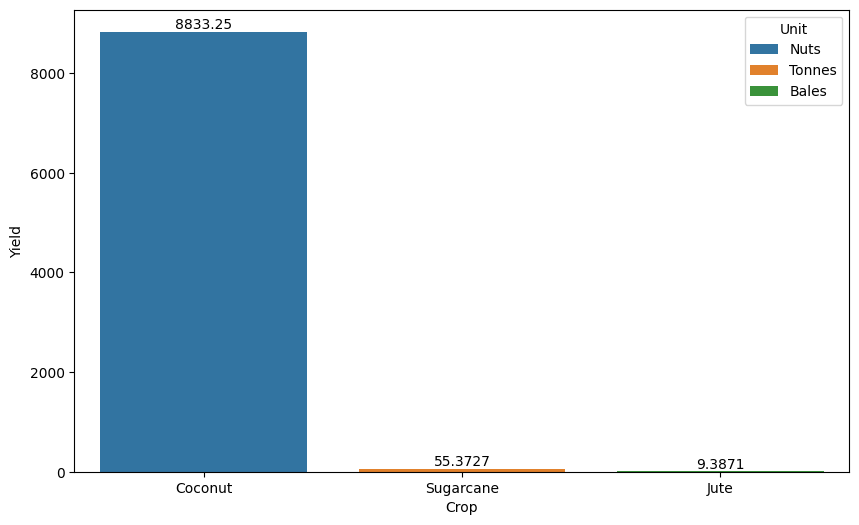

In [14]:
new = crop_df.groupby(['Production Units','Crop'])['Yield'].mean().astype('float').reset_index()

highestBales = new.loc[new['Production Units']=='Bales','Yield'].max()
highestNuts = new.loc[new['Production Units']=='Nuts','Yield'].max()
highestTonnes = new.loc[new['Production Units']=='Tonnes','Yield'].max()

crop1 = new.loc[new['Yield'] == highestNuts, 'Crop'].iloc[0]
crop2 = new.loc[new['Yield'] == highestTonnes, 'Crop'].iloc[0]
crop3 = new.loc[new['Yield'] == highestBales, 'Crop'].iloc[0]

print("Crop with highest average yield in Nuts is", crop1)
print("Crop with highest average yield in Tonnes is", crop2)
print("Crop with highest average yield in Bales is", crop3)

plot_df = pd.DataFrame({
    'Crop': [crop1, crop2, crop3],
    'Yield': [highestNuts, highestTonnes, highestBales],
    'Unit': ['Nuts', 'Tonnes', 'Bales']
})

plt.figure(figsize=(10,6))
ax = sns.barplot(x='Crop', y='Yield', hue='Unit', data=plot_df)
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.bar_label(ax.containers[2])
plt.show()


13. Which **State** has maximum production overall?

,State,Production
17,Kerala,129700649855


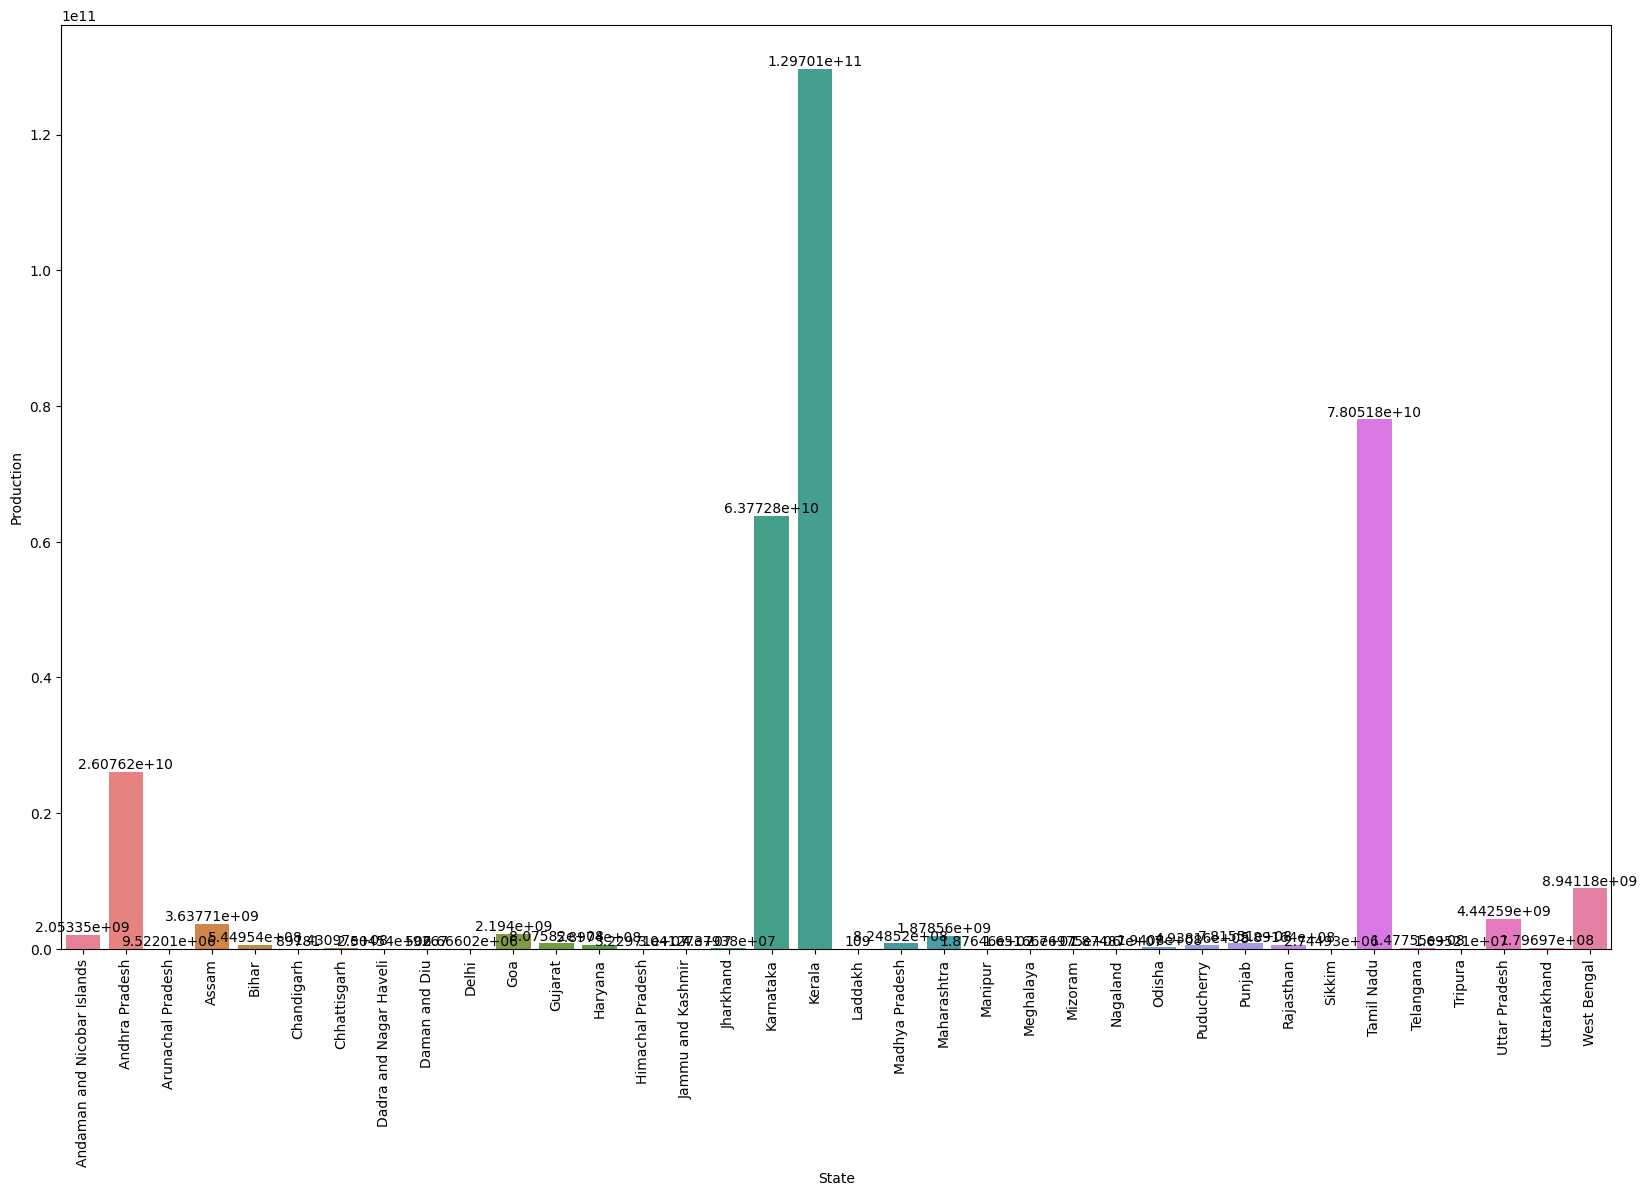

In [15]:
new = crop_df.groupby('State')['Production'].sum().astype('int').reset_index()
maxi = new['Production'].max()
display(new.loc[new['Production']==maxi,['State','Production']])

# graph 
plt.figure(figsize=(20,12))
ax = sns.barplot(x='State',y='Production',data=new,hue='State')
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=90)
plt.show()

14. Which **District** has highest **crop diversity**?

,District,Crop
57,BANGALORE RURAL,45
255,HASSAN,45
257,HAVERI,45
425,MANDYA,45
454,MYSORE,45
600,SHIMOGA,45
697,VELLORE,45


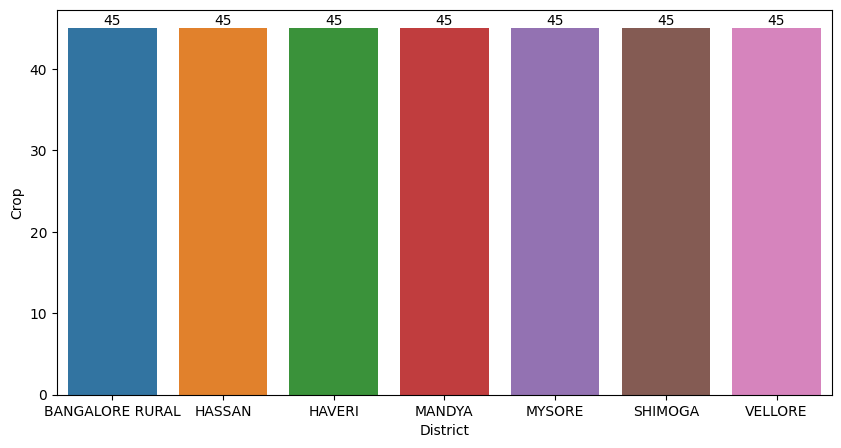

In [16]:
new = crop_df.groupby('District')['Crop'].nunique().reset_index()
highest = new['Crop'].max()
new = new.loc[new['Crop']==highest,['District','Crop']]
display(new)

#  graphical representation
plt.figure(figsize=(10,5))
ax = sns.barplot(x='District',y='Crop',hue='District',data=new)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

15. What are the **top 5 crops by total area**? (national level)

,Crop,Area
41,Rice,995813642
54,Wheat,664492581
11,Cotton(lint),232223128
46,Soyabean,204443388
2,Bajra,199095809


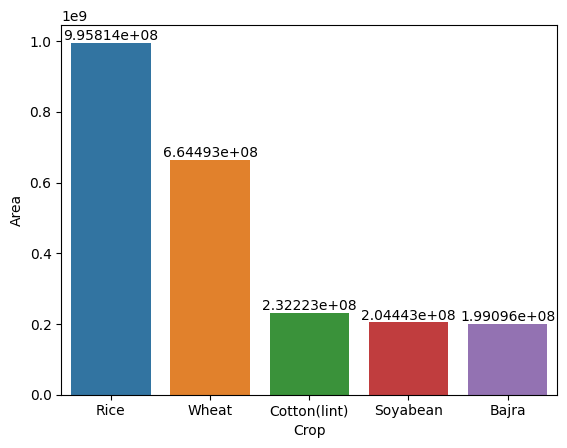

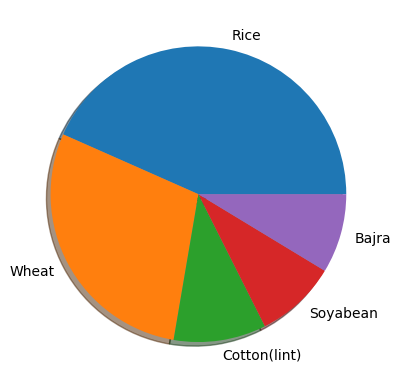

In [17]:
top5_crops = crop_df.groupby('Crop')['Area'].sum().astype('int').reset_index()
top5_crops = top5_crops.sort_values(by='Area', ascending=False).head(5)
display(top5_crops)
#  graphical representation
ax=sns.barplot(x='Crop',y='Area',hue='Crop',data=top5_crops)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
    
plt.pie(x='Area',labels='Crop',data=top5_crops,shadow=True)
plt.show()


## 🟣 **4. Crop-Wise Analysis**

16. Which crop is grown in the **largest area**?

In [18]:
cropInArea = crop_df.groupby('Crop')['Area'].sum().reset_index()
largest = cropInArea['Area'].max()
cropInArea.loc[cropInArea['Area']==largest,['Crop','Area']]

,Crop,Area
41,Rice,995813642.5



17. Which crop has the **highest production**?

In [19]:
new = crop_df.groupby('Crop')['Production'].sum().astype('int').reset_index()
highest = new['Production'].max()
new.loc[new['Production']==highest]

,Crop,Production
9,Coconut,310804772578


18. Which crops show **consistent growth trend** over years?

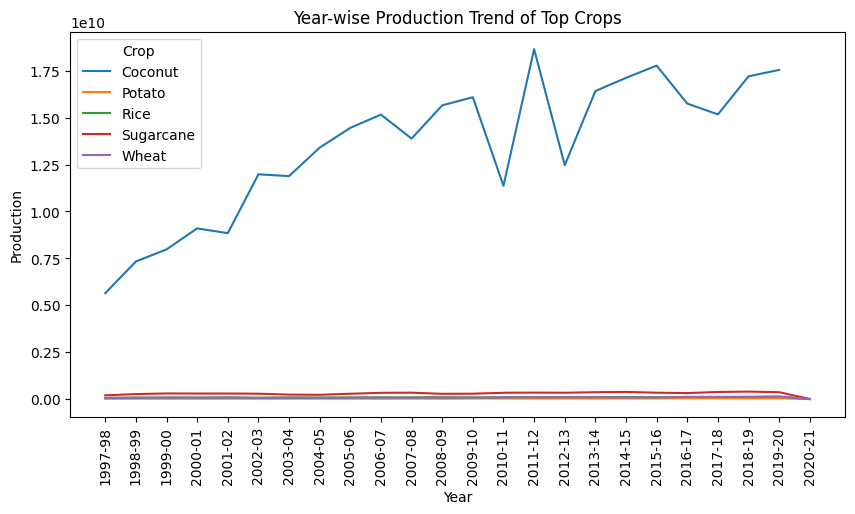

In [20]:
crop_year_prod  = crop_df.groupby(['Crop','Year'])['Production'].sum().reset_index()
top_crops = (
    crop_year_prod.groupby('Crop')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
filtered_data = crop_year_prod[crop_year_prod['Crop'].isin(top_crops)]

plt.figure(figsize=(10,5))
sns.lineplot(data=filtered_data, x='Year', y='Production', hue='Crop')
plt.title("Year-wise Production Trend of Top Crops")
plt.xticks(rotation=90)
plt.show()




19. Compare **Area vs Production** for each crop — efficiency?

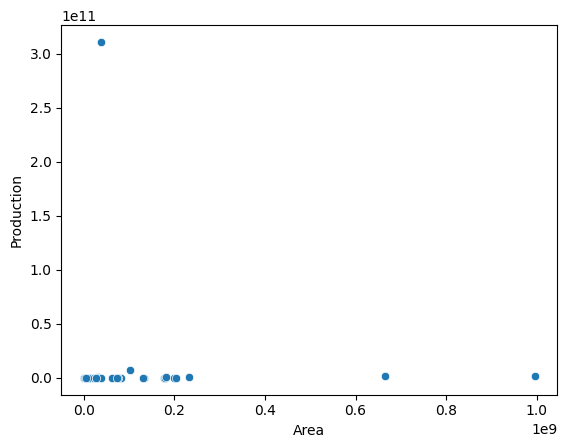

In [21]:
new=crop_df.groupby('Crop')[['Area','Production']].sum().astype('int').reset_index()
ax=sns.scatterplot(x='Area',y='Production',data=new)
for container in ax.containers:
    ax.set_label('Crop')
plt.show()

## 🔴 **5. State-Wise Patterns**
> Charts: Stacked bar (Year vs Crop), Heatmap (State vs Crop)

20. Which State contributes the **maximum production**?

In [22]:
new=crop_df.groupby('State')['Production'].max().reset_index()
max = new['Production'].max()
new.loc[new['Production']==max,'State']

30    Tamil Nadu
Name: State, dtype: object

21. Which State shows **highest crop yield**?

In [23]:
new=crop_df.groupby('State')['Yield'].sum().astype('int').reset_index()
max = new['Yield'].max()
new.loc[new['Yield']==max,['State','Yield']]

,State,Yield
30,Tamil Nadu,5617809


22. Which States specialize in **what crops**?

In [24]:
# First, aggregate max production per crop per state
new = crop_df.groupby(['State','Crop'])['Production'].max().reset_index()

# Now, find the crop with maximum production for each state
prominent_crop = new.loc[new.groupby('State')['Production'].idxmax()].reset_index(drop=True)
prominent_crop['Production']=prominent_crop['Production'].astype('int')

23. Identify States with **declining production** trends.


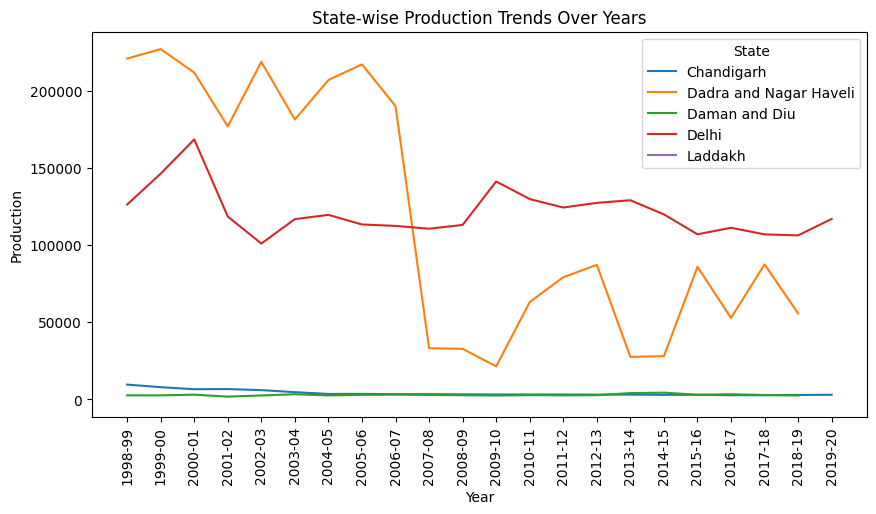

In [25]:
state_year_prod = (
    crop_df.groupby(['Year', 'State'])['Production']
      .sum()
      .reset_index()
)
top_states = (
    state_year_prod.groupby('State')['Production']
    .sum()
    .sort_values(ascending=True)
    .head(5)
    .index
)
filtered_states = state_year_prod[state_year_prod['State'].isin(top_states)]

plt.figure(figsize=(10,5))
sns.lineplot(data=filtered_states, x='Year', y='Production', hue='State')
plt.title("State-wise Production Trends Over Years")
plt.xticks(rotation=90)
plt.show()


24. Which State has **highest area utilization** over years?

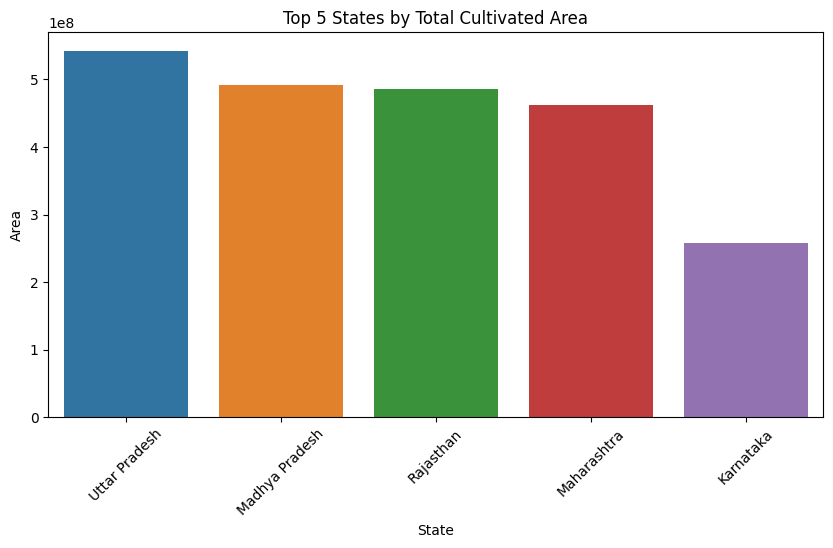

In [26]:
stateArea = crop_df.groupby('State')['Area'].sum().astype('int').sort_values(ascending=False).head(5).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=stateArea, x='State', y='Area',hue='State')
plt.title("Top 5 States by Total Cultivated Area")
plt.xticks(rotation=45)
plt.show()


## 🟠 **6. Year-Wise Trends**

> Charts: Line charts, seasonal line plots

25. How has **total agricultural production changed** over time?

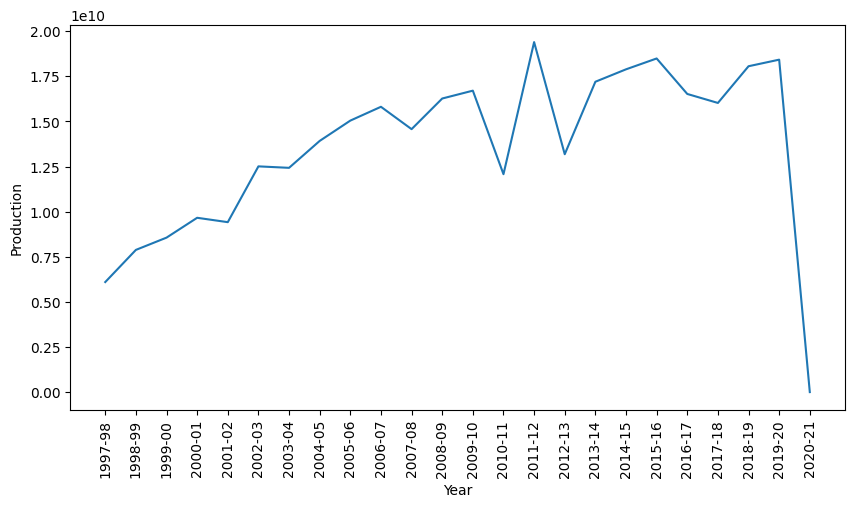

In [27]:
year_wise_PR = crop_df.groupby('Year')['Production'].sum().astype('int').reset_index()
plt.figure(figsize=(10,5))
ax = sns.lineplot(x='Year',y="Production",data=year_wise_PR)
plt.xticks(rotation=90)
plt.show()

26. Identify **year peaks and drops** — any drought/flood impact?

,Year
4,2001-02
6,2003-04
10,2007-08
13,2010-11
15,2012-13
19,2016-17
20,2017-18
23,2020-21


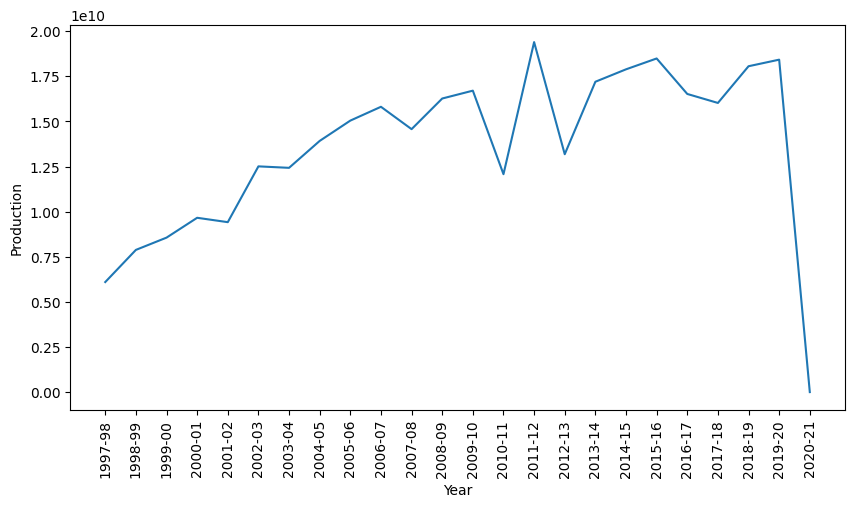

In [28]:
year_peak_drop = crop_df.groupby('Year')['Production'].sum().reset_index()
year_peak_drop['Production']=year_peak_drop['Production'].diff()

def peak_drop(n):
    if n<-(10000000):
        return True
    else:
        return False
    
plt.figure(figsize=(10,5))
ax = sns.lineplot(x='Year',y="Production",data=year_wise_PR)
plt.xticks(rotation=90)

year_peak_drop['Production']=year_peak_drop['Production'].apply(peak_drop)
year_peak_drop.loc[year_peak_drop['Production'],['Year']]

27. Which crops increase during **specific years**?

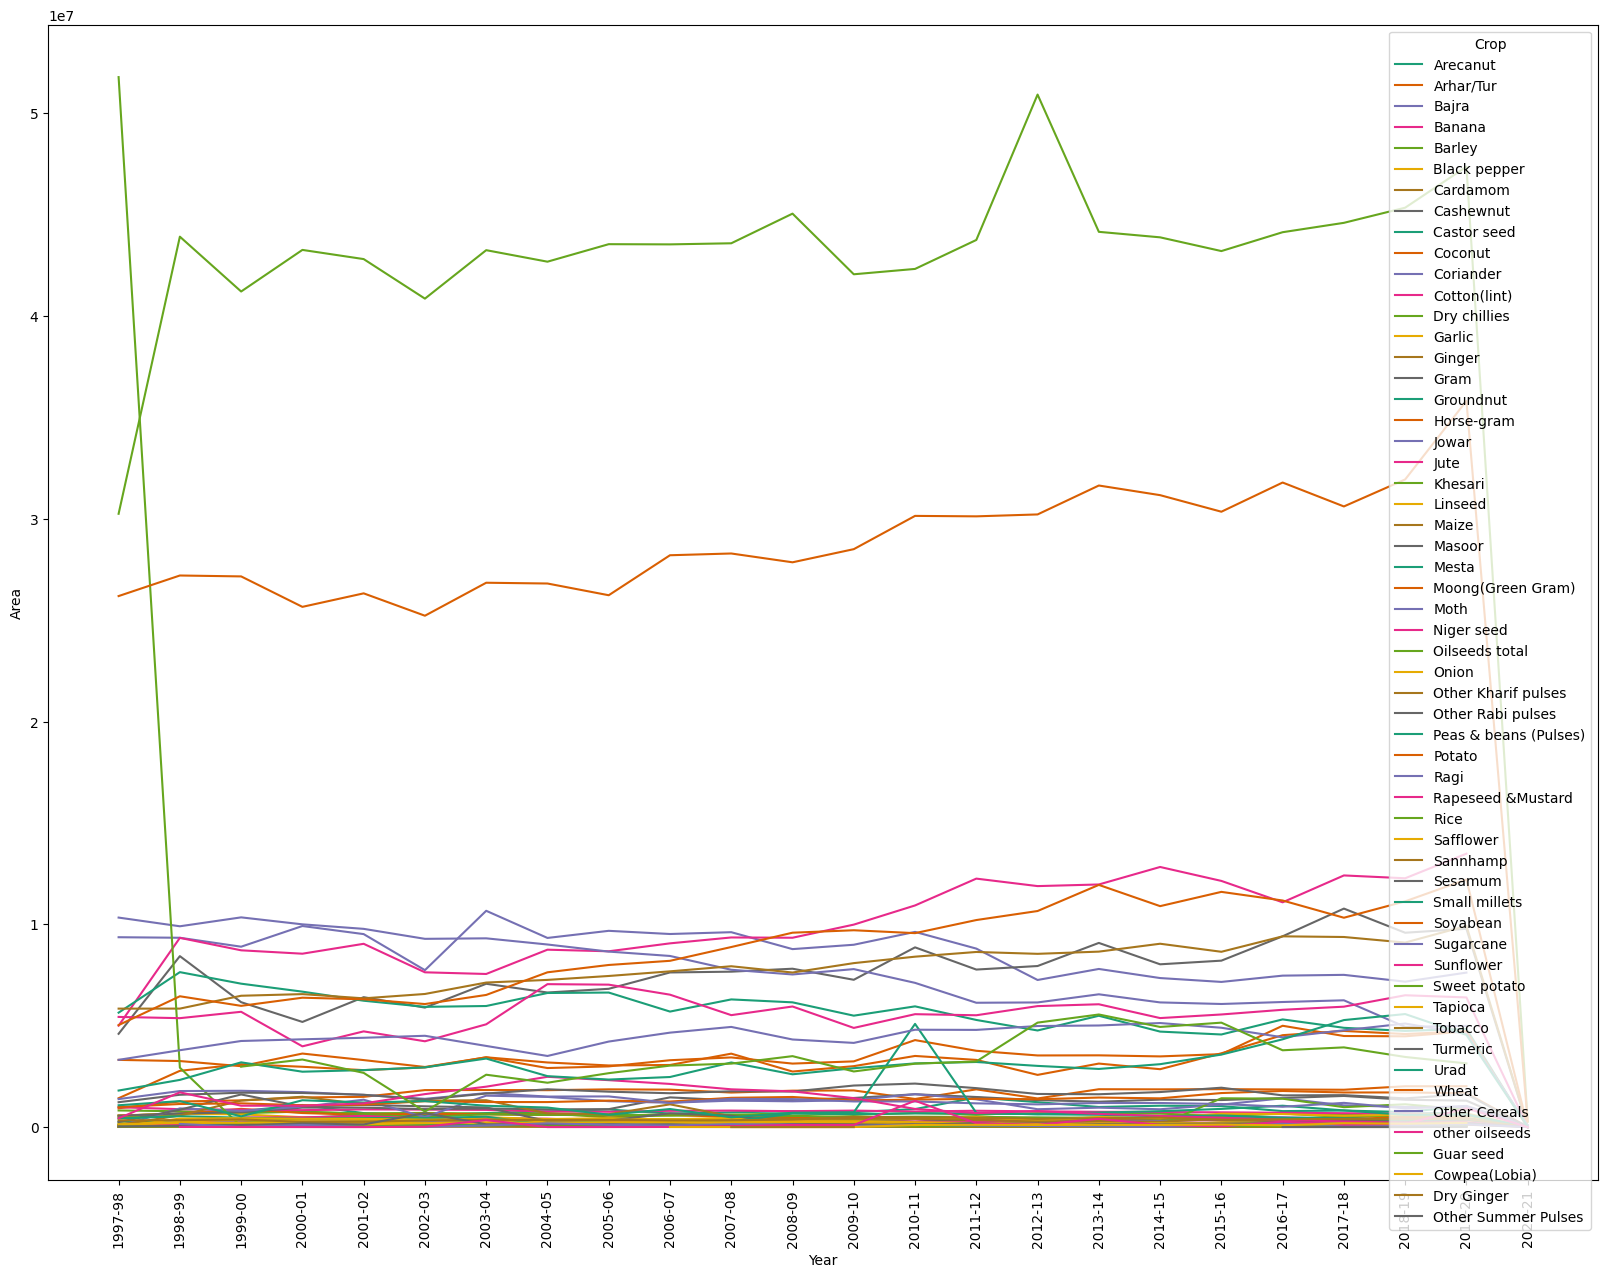

In [29]:
from sympy import rotations


Crop_specific_year = crop_df.groupby(['Year','Crop'])['Area'].sum().reset_index()
plt.figure(figsize=(20,15))
ax = sns.lineplot(x='Year',y='Area',hue='Crop',data=Crop_specific_year,palette='Dark2')
plt.xticks(rotation=90)
plt.show()

28. What are **seasonal patterns** (Kharif vs Rabi)?

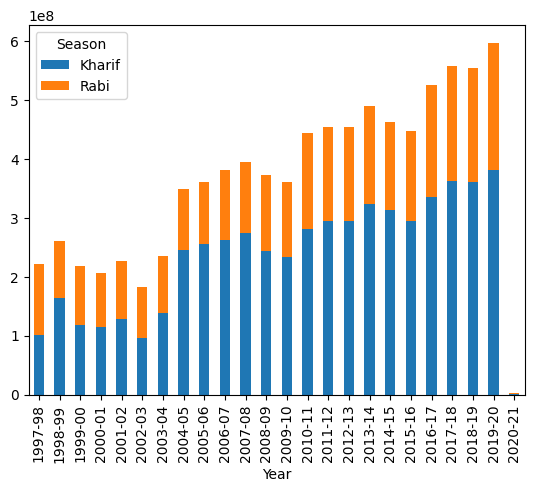

In [30]:
new = crop_df.groupby(['Year','Season'])['Production'].sum().astype('int').reset_index()
seasonal_pattern = new[(new['Season']=='Kharif')|(new['Season']=='Rabi')]
pivot_season = seasonal_pattern.pivot_table(index='Year',columns='Season',values='Production')
pivot_season.plot(kind='bar',stacked=True)
plt.show()

## 🟤 **7. Season-Wise Analysis**

> Charts: grouped boxplot (Crop vs Yield vs Season)

---

29. Which season has **maximum area**?

In [31]:
seasonal_area = crop_df.groupby('Season')['Area'].sum().astype('int').reset_index()
max_area=seasonal_area['Area'].max()
seasonal_area.loc[seasonal_area['Area']==max_area,['Season','Area']]

,Season,Area
1,Kharif,1956256222


30. Which season has **maximum production**?

In [32]:
seasonal_production = crop_df.groupby('Season')['Production'].sum().astype('int').reset_index()
max_Pro=seasonal_production['Production'].max()
seasonal_production.loc[seasonal_production['Production']==max_Pro,['Season','Production']]

,Season,Production
4,Whole Year,316554001653


31. Which crops dominate **each season**?

<Axes: xlabel='Season', ylabel='Production'>

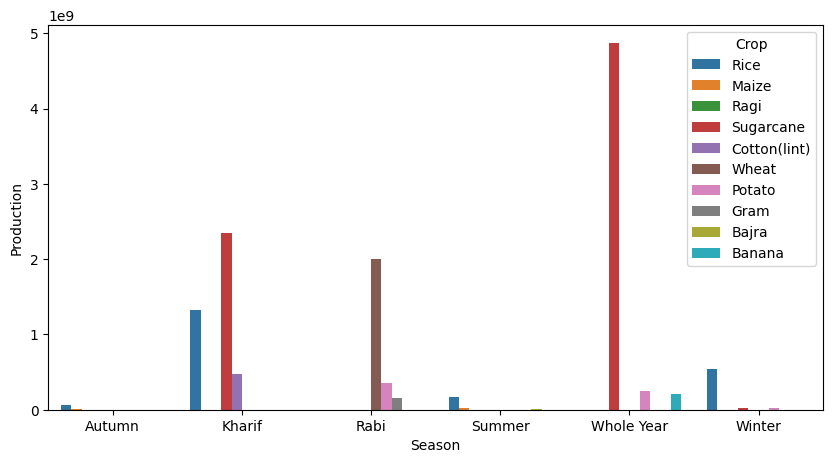

In [33]:
dom_season = crop_df.groupby(['Crop','Season'])['Production'].sum().reset_index()
dom_season = dom_season[dom_season['Crop']!='Coconut']
top_crops_per_season = dom_season.sort_values(['Season', 'Production'], ascending=[True, False]).groupby('Season').head(3)
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_crops_per_season,
    x='Season',
    y='Production',
    hue='Crop'
)


32. Does **yield differ by season** for same crop?

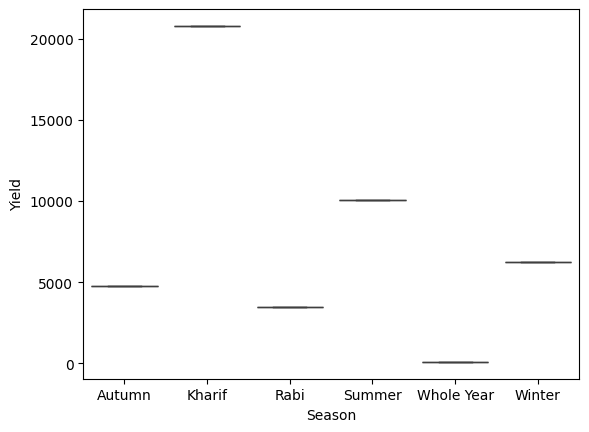

In [34]:
yield_diff=crop_df[['Season','Crop','Yield']]
selected_crop = 'Rice'
yield_diff=yield_diff[yield_diff['Crop']==selected_crop]
yield_diff=yield_diff.groupby(['Season','Crop'])['Yield'].sum().reset_index()
sns.boxplot(x='Season',y='Yield',data=yield_diff)
plt.show()

## ⚫ **8. District-Level Insights**

33. Which district has **highest production density**? (production/area)


In [35]:
new_df = crop_df
new_df['density'] = crop_df['Production']/crop_df['Area']
hig_den = new_df['density'].max()
new_df.loc[new_df['density']==hig_den,'District']

228210    TINSUKIA
Name: District, dtype: object

34. Identify **top productive clusters** within States.

In [36]:
clusters_state = crop_df.groupby(['State','District'])['Production'].sum().reset_index()
clusters_state.sort_values(['State', 'Production'], ascending=[True, False])
top_clusters = clusters_state.groupby('State').head(3)
top_clusters

,State,District,Production
0,Andaman and Nicobar Islands,Andaman and Nicobar Islands,2.476547e+08
1,Andaman and Nicobar Islands,NICOBARS,1.299981e+09
2,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,2.120045e+08
4,Andhra Pradesh,ADILABAD,1.357820e+07
5,Andhra Pradesh,ANANTAPUR,1.289367e+08
...,...,...,...
760,Uttarakhand,BAGESHWAR,1.200488e+06
761,Uttarakhand,CHAMOLI,2.463021e+06
772,West Bengal,24 PARAGANAS NORTH,1.254157e+09
773,West Bengal,24 PARAGANAS SOUTH,1.191063e+09


35. Find districts that **specialize in specific crops**.

In [37]:
sisc = crop_df.groupby(['District','Crop'])['Area'].sum().reset_index('Crop')
dominant_crop = sisc.sort_values(['District','Area'], ascending=[True, False]).groupby('District').head(1)

dominant_crop

,Crop,Area
District,,
24 PARAGANAS NORTH,Rice,5984271.0
24 PARAGANAS SOUTH,Rice,9350868.0
ADILABAD,Cotton(lint),4940913.0
AGAR MALWA,Soyabean,850188.0
AGRA,Wheat,3038116.0
...,...,...
YADGIR,Rice,721306.0
YAMUNANAGAR,Wheat,1719066.0
YANAM,Rice,12180.0


36. Distribution of **Area and Production** at district level.

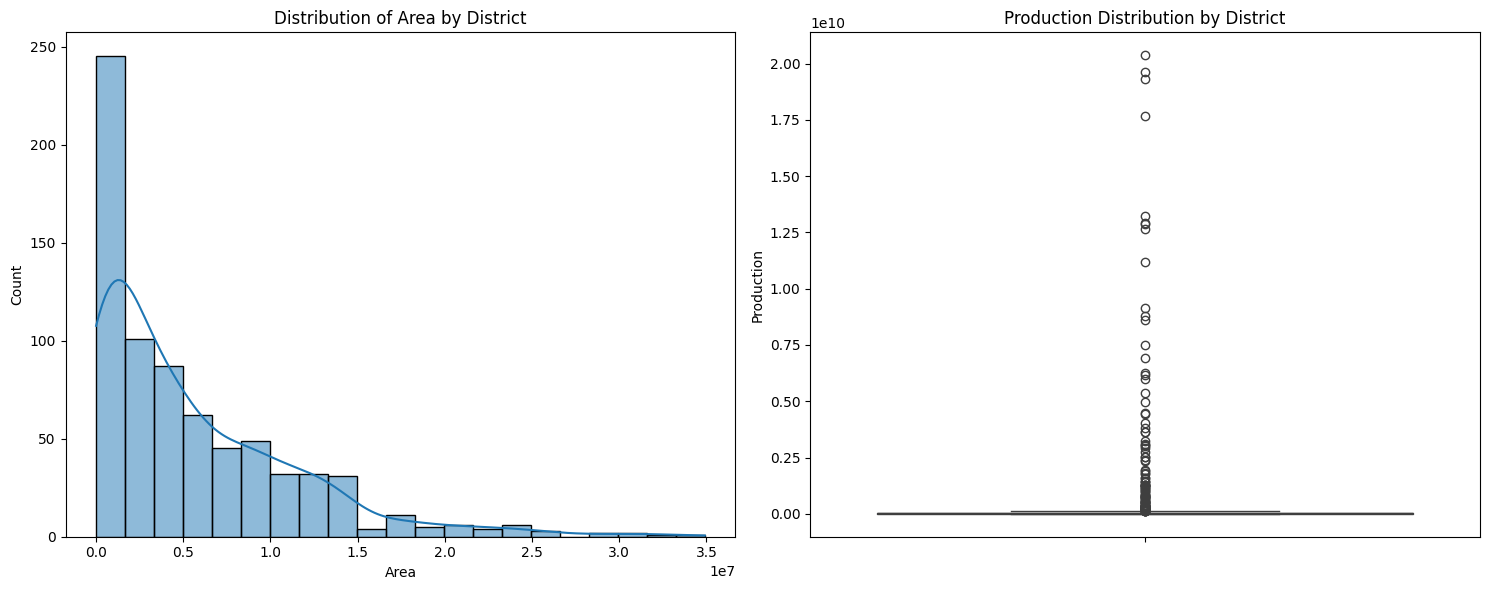

In [38]:
# Your aggregation (good!)
Area_and_Pro = crop_df.groupby('District')[['Area','Production']].sum().astype('int').reset_index()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Area distribution (histogram)
sns.histplot(data=Area_and_Pro, x='Area', kde=True, ax=ax1)
ax1.set_title('Distribution of Area by District')
ax1.set_xlabel('Area')

# Right: Production boxplot
sns.boxplot(data=Area_and_Pro, y='Production', ax=ax2)
ax2.set_title('Production Distribution by District')
ax2.set_ylabel('Production')

plt.tight_layout()
plt.show()


# ⭐ **Yield-Specific Questions**
---

37. Calculate **Yield = Production/Area** and analyze:

* High yield crops?
* Low yield crops?

In [43]:
new = crop_df.sort_values(by='Yield',inplace=True)
crop_df

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,density
18198,Kerala,KANNUR,Sesamum,2001-02,Kharif,4.0,Hectare,NaN,Tonnes,0.000000,NaN
61151,Kerala,THIRUVANANTHAPURAM,Sugarcane,2004-05,Whole Year,3.0,Hectare,NaN,Tonnes,0.000000,NaN
252986,Maharashtra,AURANGABAD,Rapeseed &Mustard,2018-19,Rabi,10.0,Hectare,NaN,Tonnes,0.000000,NaN
63497,Madhya Pradesh,SHIVPURI,Other Kharif pulses,2006-07,Kharif,252.0,Hectare,NaN,Tonnes,0.000000,NaN
105457,Madhya Pradesh,BHIND,Coriander,2008-09,Whole Year,1.0,Hectare,NaN,Tonnes,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...
279641,Assam,TINSUKIA,Coconut,2019-20,Whole Year,71.0,Hectare,2340000.0,Nuts,32957.746479,32957.746479
119409,Tamil Nadu,ERODE,Coconut,2008-09,Whole Year,10014.0,Hectare,331800000.0,Nuts,33133.612942,33133.612942
83550,West Bengal,BIRBHUM,Coconut,2006-07,Whole Year,509.0,Hectare,19749200.0,Nuts,38800.000000,38800.000000
228210,Assam,TINSUKIA,Coconut,2018-19,Whole Year,72.0,Hectare,3165000.0,Nuts,43958.333333,43958.333333


38. Which States **optimize yield** instead of area?
39. How does yield change over the years?



# 🧠 **Correlation & Multivariate Analysis**

40. Does **Area strongly correlate** with Production?
41. Is there a **relationship between Season and Yield**?
42. Correlation between **Year and yield**?
43. How does **State influence productivity**?

> Tools: pairplot, heatmap, scatter

---

# 🔍 **Advanced Research Questions**

44. Which crops are **climate-sensitive**? Look for sharp production drops.
45. Can we detect **crop rotation patterns** in districts?
46. Which States are **improving fastest** (yearly CAGR of production)?
47. Forecast next year production using **simple trend model**.
48. Identify **high potential crops** for specific States.

---

# 🎯 **Insight-Based Business Questions**

49. Which crops should **State X** promote?
50. Where should the government invest to **boost yield**?
51. Which districts need **better irrigation support**?
52. Which crops are **declining** and need intervention?
53. What are the **top 3 strategic recommendations**?

---

# 📌 **Bonus Feature Engineering**

54. Create **Yield Rate** = Production/Area.
55. Create **Relative Contribution** % for each crop by State.
56. Create **Seasonal Index** for crops.
57. Calculate **CAGR** of production by crop.